In [190]:
"""
Homework 2 Who tends to exercise more?
Jackson School of Global Affairs                 
                                                 
 Created by Ardina Hasanbasri for GLBL 5021      
                                                 
Additional reference code and data used:        
Békés & Kézdi (2021) see more code below         
https://gabors-data-analysis.com/               
                                            
"""

# Note: Feel free to move this code to jupyter notebook if you prefer. 

#-----------------------------------#
# SETTING UP YOUR WORKSPACE #
# ----------------------------------#

# Feel free to add or delete
import os
import sys
import warnings
import numpy as np
import pandas as pd
import pyfixest as pf
import seaborn as sns
import matplotlib.pyplot as plt
import pyreadstat
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.metrics import mean_squared_error, r2_score, log_loss
import statsmodels.formula.api as smf
from typing import List
import marginaleffects as me
warnings.filterwarnings("ignore") 

share = pd.read_csv("https://osf.io/download/kbjzp/")

#-----------------------------------------------------------#
# Sample Selection and Creating New Data                    #
# ----------------------------------------------------------#

share = share.query("wave==4 & age>=50 & age<=64")

# Some reminder code to help explore data. 
share["br015"].unique()
share["mar_stat"].value_counts()
share["bmi"].describe()

count    26254.000000
mean        25.195472
std          9.284344
min        -15.000000
25%         23.243801
50%         26.026175
75%         29.372396
max         88.376396
Name: bmi, dtype: float64

In [191]:
share.index = share.mergeid
share = share.drop(columns=['mergeid'])

# Part 1

## 1.1

In [192]:
share.describe()

,wave,country,country_mod,int_year,int_month,female,age,eduyears_mod,sphus,br015,smoking,ever_smoked,income_pct_w4,bmi,mar_stat
count,26254.0,26254.000000,26254.000000,26254.000000,26254.000000,26254.000000,26254.000000,26254.000000,26254.000000,26254.000000,26254.000000,26254.000000,26254.000000,26254.000000,26254.000000
mean,4.0,22.593205,349.048640,2011.005028,5.797364,0.562048,57.572903,10.149901,2.972538,2.252114,3.835796,2.528948,6.021025,25.195472,1.731165
std,0.0,8.230092,241.682133,0.236737,2.712384,0.496145,3.903833,6.681391,1.525931,1.879895,2.241819,3.172209,2.943781,9.284344,2.722536
min,4.0,11.000000,40.000000,2010.000000,1.000000,0.000000,50.000000,-15.000000,-15.000000,-15.000000,-15.000000,-15.000000,1.000000,-15.000000,-15.000000
25%,4.0,16.000000,203.000000,2011.000000,4.000000,0.000000,54.299999,8.000000,2.000000,1.000000,1.000000,1.000000,4.000000,23.243801,1.000000
50%,4.0,20.000000,250.000000,2011.000000,5.000000,1.000000,57.799999,11.000000,3.000000,2.000000,5.000000,1.000000,6.000000,26.026175,1.000000
75%,4.0,32.000000,616.000000,2011.000000,8.000000,1.000000,60.900002,14.000000,4.000000,4.000000,5.000000,5.000000,9.000000,29.372396,3.000000
max,4.0,35.000000,756.000000,2012.000000,12.000000,1.000000,64.000000,25.000000,5.000000,4.000000,5.000000,5.000000,10.000000,88.376396,6.000000


In [193]:
cols_to_filter = share.columns.difference(['female'])
share_filtered = share[(share[cols_to_filter] > 0).all(axis=1)].dropna(subset=cols_to_filter)

In [194]:
share_filtered.describe()

,wave,country,country_mod,int_year,int_month,female,age,eduyears_mod,sphus,br015,smoking,ever_smoked,income_pct_w4,bmi,mar_stat
count,23926.0,23926.000000,23926.000000,23926.000000,23926.000000,23926.000000,23926.000000,23926.000000,23926.000000,23926.00000,23926.000000,23926.000000,23926.000000,23926.000000,23926.000000
mean,4.0,22.861364,342.346945,2011.001546,5.824459,0.558597,57.523869,11.432208,3.030594,2.34590,3.932208,2.872607,6.054585,26.948607,2.002508
std,0.0,8.237887,237.699239,0.236567,2.713939,0.496565,3.902150,4.072558,1.071325,1.31931,1.769497,1.995980,2.937472,4.865537,1.713964
min,4.0,11.000000,40.000000,2010.000000,1.000000,0.000000,50.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,13.493000,1.000000
25%,4.0,16.000000,203.000000,2011.000000,4.000000,0.000000,54.299999,9.000000,2.000000,1.00000,1.000000,1.000000,4.000000,23.665245,1.000000
50%,4.0,23.000000,250.000000,2011.000000,6.000000,1.000000,57.700001,12.000000,3.000000,2.00000,5.000000,1.000000,6.000000,26.277285,1.000000
75%,4.0,32.000000,528.000000,2011.000000,8.000000,1.000000,60.900002,14.000000,4.000000,4.00000,5.000000,5.000000,9.000000,29.411764,3.000000
max,4.0,35.000000,756.000000,2012.000000,12.000000,1.000000,64.000000,25.000000,5.000000,4.00000,5.000000,5.000000,10.000000,88.376396,6.000000


## 1.2

In [195]:
share_filtered['exercise'] = np.where(share_filtered['br015'] <= 2, 1, 0)

In [196]:
share_filtered.value_counts('exercise', normalize=True)

exercise
1    0.570384
0    0.429616
Name: proportion, dtype: float64

I have defined excercising as engaging in a physical activity at least once a week. One or to three times a month is not enough and could include people who just take a brisk walk to the grocery shop. Per this definition, approximately 57% of the people in the sample exercise.

## 1.3

In [197]:
share_filtered['marriage'] = np.where(share_filtered['mar_stat'] <= 2, 1, 0)

In [198]:
share_filtered.value_counts('marriage', normalize=True)

marriage
1    0.743459
0    0.256541
Name: proportion, dtype: float64

# Part 2

## 2.1

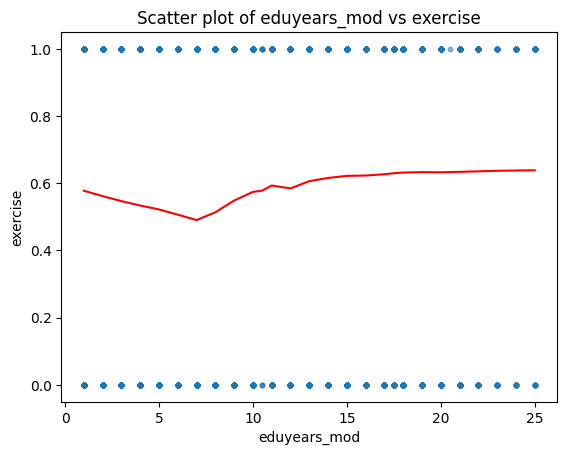

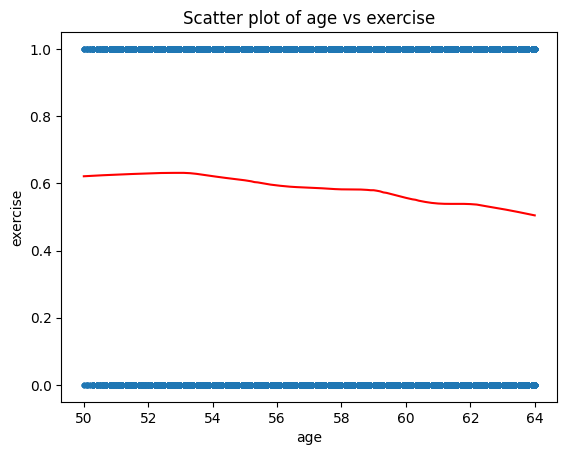

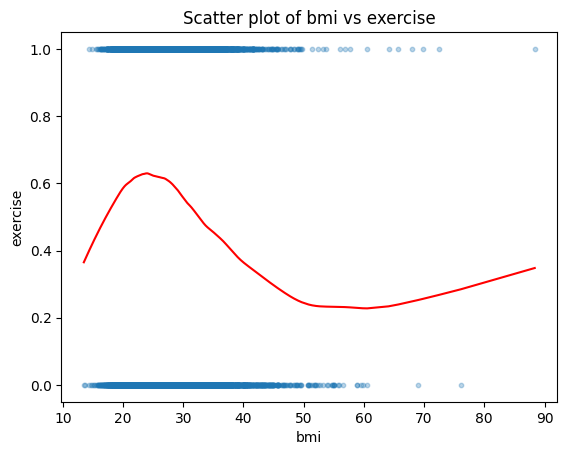

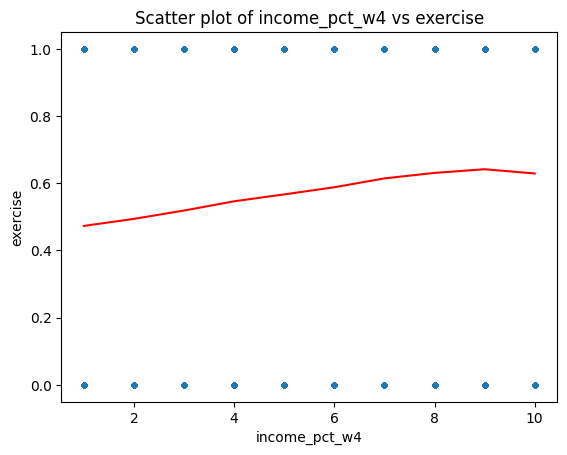

In [199]:
for col in ['eduyears_mod', 'age', 'bmi', 'income_pct_w4']:

    lowess_fit = lowess(
        endog=share_filtered['exercise'],
        exog=share_filtered[col],
        frac=0.3   # smoothing parameter 
    ) 

    plt.scatter(share_filtered[col], share_filtered['exercise'], alpha=0.3, s=10)
    plt.plot(lowess_fit[:, 0], lowess_fit[:, 1], color='red')
    plt.xlabel(col)
    plt.ylabel('exercise')
    plt.title(f'Scatter plot of {col} vs exercise')
    plt.show()

## 2.2

In [200]:
# Create splines 
x = share_filtered["eduyears_mod"].to_numpy()
share_filtered["eduyears_mod_0_7"] = np.minimum(x, 7.0)
share_filtered["eduyears_mod_7_17"] = np.minimum(np.maximum(x - 7.0, 0.0), 17.0-7.0)
share_filtered["eduyears_mod_17"] = np.maximum(x - 17.0, 0.0)

x = share_filtered["bmi"].to_numpy()
share_filtered["bmi_0_24"] = np.minimum(x, 24.0)
share_filtered["bmi_24_56"] = np.minimum(np.maximum(x - 24.0, 0.0), 56.0-24.0)
share_filtered["bmi_56"] = np.maximum(x - 56.0, 0.0)

x = share_filtered["income_pct_w4"].to_numpy()
share_filtered["income_0_9"] = np.minimum(x, 9.0)
share_filtered["income_9"] = np.maximum(x - 9.0, 0.0)

I have decided to create splines for BMI, income, and years of education, as for these variables, the graphs show possible non-linearity. I have chosen to create the splines at points where the lowess curve takes a turn from being positive to negative or vice versa (ecuation, income, bmi) or in the middle of curves which have too much of a curvature (education)

## 2.3

In [201]:
reg_exc_femage = pf.feols("exercise~female+age", data=share_filtered, vcov="HC1")
reg_exc_all = pf.feols("exercise~female+age+bmi_0_24+bmi_24_56+bmi_56+marriage+income_0_9+income_9+eduyears_mod_0_7+eduyears_mod_7_17+eduyears_mod_17", data=share_filtered, vcov="HC1")
reg_exc_allcountry = pf.feols("exercise~female+age+bmi_0_24+bmi_24_56+bmi_56+marriage+income_0_9+income_9+eduyears_mod_0_7+eduyears_mod_7_17+eduyears_mod_17+C(country_mod)", data=share_filtered, vcov="HC1")

pf.etable([reg_exc_femage, reg_exc_all, reg_exc_allcountry],
          head_order="h",
          model_heads=["exercise", "exercise", "exercise"],
          labels={"Intercept": "Constant"}          
)

GT(_tbl_data=   level_0                level_1                       0  \
0     coef                 female  -0.097*** <br> (0.006)   
1     coef                    age  -0.009*** <br> (0.001)   
2     coef               bmi_0_24                           
3     coef              bmi_24_56                           
4     coef                 bmi_56                           
5     coef               marriage                           
6     coef             income_0_9                           
7     coef               income_9                           
8     coef       eduyears_mod_0_7                           
9     coef      eduyears_mod_7_17                           
10    coef        eduyears_mod_17                           
11    coef   C(country_mod)[T.56]                           
12    coef  C(country_mod)[T.203]                           
13    coef  C(country_mod)[T.208]                           
14    coef  C(country_mod)[T.233]                           
15    coef  C(country_mod)[T.250]                           
16    coef  C(country_mod)[T.276]                           
17    coef  C(country_mod)[T.348]                           
18    coef  C(country_mod)[T.380]                           
19    coef  C(country_mod)[T.528]                           
20    coef  C(country_mod)[T.616]                           
21    coef  C(country_mod)[T.620]                           
22    coef  C(country_mod)[T.705]                           
23    coef  C(country_mod)[T.724]                           
24    coef  C(country_mod)[T.752]                           
25    coef  C(country_mod)[T.756]                           
26    coef               Constant   1.125*** <br> (0.047)   
27   stats           Observations                   23926   
28   stats              S.E. type                  hetero   
29   stats          R<sup>2</sup>                   0.014   
30   stats     Adj. R<sup>2</sup>                   0.014   

                         1                       2  
0   -0.093*** <br> (0.006)  -0.093*** <br> (0.006)  
1   -0.007*** <br> (0.001)  -0.008*** <br> (0.001)  
2    0.011*** <br> (0.003)   0.011*** <br> (0.003)  
3   -0.013*** <br> (0.001)  -0.013*** <br> (0.001)  
4    0.032*** <br> (0.009)    0.029** <br> (0.009)  
5      -0.007 <br> (0.008)     -0.001 <br> (0.008)  
6    0.016*** <br> (0.001)   0.016*** <br> (0.001)  
7    -0.030** <br> (0.010)   -0.027** <br> (0.010)  
8      -0.003 <br> (0.003)     -0.001 <br> (0.004)  
9    0.006*** <br> (0.001)      0.002 <br> (0.001)  
10     -0.007 <br> (0.005)     -0.005 <br> (0.004)  
11                          -0.104*** <br> (0.015)  
12                          -0.100*** <br> (0.015)  
13                             -0.031 <br> (0.018)  
14                              0.010 <br> (0.014)  
15                          -0.119*** <br> (0.015)  
16                           0.100*** <br> (0.023)  
17                          -0.113*** <br> (0.017)  
18                          -0.134*** <br> (0.017)  
19                           0.111*** <br> (0.017)  
20                          -0.149*** <br> (0.022)  
21                          -0.196*** <br> (0.021)  
22                              0.016 <br> (0.017)  
23                          -0.217*** <br> (0.018)  
24                            0.063** <br> (0.024)  
25                             -0.020 <br> (0.016)  
26   0.745*** <br> (0.080)   0.850*** <br> (0.081)  
27                   23926                   23926  
28                  hetero                  hetero  
29                   0.035                   0.062  
30                   0.034                   0.061  , _body=<great_tables._gt_data.Body object at 0x000001DA8273EC10>, _boxhead=Boxhead([ColInfo(var='level_0', type=<ColInfoTypeEnum.row_group: 3>, column_label='level_0', column_align='center', column_width=None), ColInfo(var='level_1', type=<ColInfoTypeEnum.stub: 2>, column_label='level_1', column_align='center', column_width=None), ColIn

## 2.4

In model 1, the coefficient on female is -0.097 whilst for models 2 and 3, it's -0.093 (all significant at p<0.001). For model 1, this means that females (holding all else constant) are 9.7% less likely to exercise than men. For models 2 and 3, that difference in probabilities is 9.3%.

In models 1, 2, and 3, the coefficients on age are -0.009, -0.007, and -0.008 respectively (all significant at p<0.001). This means that as one gets older by a year, their predicted chance of exercising (holding all else constant) decrease by 0.9%, 0.7%, and 0.8%, respectively per the relevant model.

In models 2 and 3, the coefficients on bmi_0_24 are 0.011 (both significant at p<0.001). This means that as one increases their BMI by 1, their predicted chance of exercising (holding all else constant) increases by 1.1%, if their BMI is between 0 (not inclusive) and 24 (inclusive). The coefficients on bmi_24_56 are -0.013 (both significant at p<0.001). This means that as one increases their BMI by 1, their predicted chance of exercising (holding all else constant) decreases by 1.3%, if their BMI is between 24 (not inclusive) and 24 (inclusive). The coefficients on bmi_56 are 0.032 and 0.029 respectively (one significant at p<0.001 and the other at p<0.01). This means that as one increases their BMI by 1, their predicted chance of exercising (holding all else constant) increases by 3.2% and 2.9% respectively, if their BMI is above 56.

## 2.5

It appears that men tend to exercise more (or at least declare that they do so). This could be explained by differences in declaration (men might be more prone to label more activities as exercise (such as work around the house etc.)). It could also be explained by a larger portion of men in blue collar jobs.

It is interesting to see that education does not appear to have much influence on exercising besides the spline eduyears_mod_7_17 (but even there, the effects are low even with strong significance). This might be because we don't have enough observations in the other two splines. The small effect in 7_17 might be explained that as one becomes more educated, they become more aware of the health effects of a sedentary lifestyle. Thus, some people become motivated to move at least once a week.

For BMI, the biggest surprise lies in the spline bmi_56. People with a BMI above 56 are morbidly obese, so one would imagine almost no exercise compared to people with lower BMIs. However, it might be thas as people increase their BMI in the above56 spline, their health is so bad that they become forced by their caretakers to move at least a bit to minimise the negative effects on their health.

## 2.6

In [202]:
reg_exc_all_nospline = pf.feols("exercise~female+age+bmi+marriage+income_pct_w4+eduyears_mod", data=share_filtered, vcov="HC1")

pf.etable([reg_exc_all_nospline, reg_exc_all],
          head_order="h",
          model_heads=["exercise", "exercise"],
          labels={"Intercept": "Constant"}
)

GT(_tbl_data=   level_0             level_1                       0                       1
0     coef              female  -0.099*** <br> (0.006)  -0.093*** <br> (0.006)
1     coef                 age  -0.007*** <br> (0.001)  -0.007*** <br> (0.001)
2     coef                 bmi  -0.009*** <br> (0.001)                        
3     coef            marriage     -0.002 <br> (0.008)     -0.007 <br> (0.008)
4     coef       income_pct_w4   0.014*** <br> (0.001)                        
5     coef        eduyears_mod   0.003*** <br> (0.001)                        
6     coef            bmi_0_24                           0.011*** <br> (0.003)
7     coef           bmi_24_56                          -0.013*** <br> (0.001)
8     coef              bmi_56                           0.032*** <br> (0.009)
9     coef          income_0_9                           0.016*** <br> (0.001)
10    coef            income_9                           -0.030** <br> (0.010)
11    coef    eduyears_mod_0_7                             -0.003 <br> (0.003)
12    coef   eduyears_mod_7_17                           0.006*** <br> (0.001)
13    coef     eduyears_mod_17                             -0.007 <br> (0.005)
14    coef            Constant   1.152*** <br> (0.051)   0.745*** <br> (0.080)
15   stats        Observations                   23926                   23926
16   stats           S.E. type                  hetero                  hetero
17   stats       R<sup>2</sup>                   0.031                   0.035
18   stats  Adj. R<sup>2</sup>                   0.031                   0.034, _body=<great_tables._gt_data.Body object at 0x000001DA31FD9050>, _boxhead=Boxhead([ColInfo(var='level_0', type=<ColInfoTypeEnum.row_group: 3>, column_label='level_0', column_align='center', column_width=None), ColInfo(var='level_1', type=<ColInfoTypeEnum.stub: 2>, column_label='level_1', column_align='center', column_width=None), ColInfo(var='0', type=<ColInfoTypeEnum.default: 1>, column_label='(1)', column_align='center', column_width=None), ColInfo(var='1', type=<ColInfoTypeEnum.default: 1>, column_label='(2)', column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x000001DA32880950>, _spanners=Spanners([SpannerInfo(spanner_id='exercise', spanner_level=1, spanner_label='exercise', spanner_units=None, spanner_pattern=None, vars=['0', '1'], built=None)]), _heading=Heading(title=None, subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x000001DA31FD87D0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x000001DA31FDB0D0>, _source_notes=['Significance levels: * p < 0.05, ** p < 0.01, *** p < 0.001. Format of coefficient cell:\nCoefficient \n (Std. Error)'], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x000001DA31FD9910>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value',

Using the splines was a correct decision. The $R^2$ increases slightly. We also get a glimpse into the interval of education that makes the biggest difference (between 7 and 17 years) compared to the others that are not statisticall significant.

## 3.1

In [203]:
reg_exc_all_lpm = pf.feols("exercise~female+age+bmi_0_24+bmi_24_56+bmi_56+marriage+income_0_9+income_9+eduyears_mod_0_7+eduyears_mod_7_17+eduyears_mod_17", data=share_filtered, vcov="HC1")
reg_exc_all_logit = pf.feglm("exercise~female+age+bmi_0_24+bmi_24_56+bmi_56+marriage+income_0_9+income_9+eduyears_mod_0_7+eduyears_mod_7_17+eduyears_mod_17", data=share_filtered, vcov="HC1", family="logit")
reg_exc_all_probit = pf.feglm("exercise~female+age+bmi_0_24+bmi_24_56+bmi_56+marriage+income_0_9+income_9+eduyears_mod_0_7+eduyears_mod_7_17+eduyears_mod_17", data=share_filtered, vcov="HC1", family="probit")

pf.etable([reg_exc_all_lpm, reg_exc_all_logit, reg_exc_all_probit],
          head_order="h",
          model_heads=["exercise (OLS)", "exercise (Logit)", "exercise (Probit)"],
          labels={"Intercept": "Constant"}          
)

GT(_tbl_data=   level_0             level_1                       0  \
0     coef              female  -0.093*** <br> (0.006)   
1     coef                 age  -0.007*** <br> (0.001)   
2     coef            bmi_0_24   0.011*** <br> (0.003)   
3     coef           bmi_24_56  -0.013*** <br> (0.001)   
4     coef              bmi_56   0.032*** <br> (0.009)   
5     coef            marriage     -0.007 <br> (0.008)   
6     coef          income_0_9   0.016*** <br> (0.001)   
7     coef            income_9   -0.030** <br> (0.010)   
8     coef    eduyears_mod_0_7     -0.003 <br> (0.003)   
9     coef   eduyears_mod_7_17   0.006*** <br> (0.001)   
10    coef     eduyears_mod_17     -0.007 <br> (0.005)   
11    coef            Constant   0.745*** <br> (0.080)   
12   stats        Observations                   23926   
13   stats           S.E. type                  hetero   
14   stats       R<sup>2</sup>                   0.035   
15   stats  Adj. R<sup>2</sup>                   0.034   

                         1                       2  
0   -0.390*** <br> (0.027)  -0.242*** <br> (0.017)  
1   -0.031*** <br> (0.003)  -0.019*** <br> (0.002)  
2    0.046*** <br> (0.011)   0.028*** <br> (0.007)  
3   -0.054*** <br> (0.004)  -0.034*** <br> (0.002)  
4      0.160* <br> (0.068)     0.097* <br> (0.040)  
5      -0.028 <br> (0.033)     -0.017 <br> (0.020)  
6    0.068*** <br> (0.006)   0.042*** <br> (0.004)  
7    -0.127** <br> (0.044)   -0.079** <br> (0.027)  
8      -0.013 <br> (0.014)     -0.008 <br> (0.009)  
9    0.027*** <br> (0.005)   0.017*** <br> (0.003)  
10     -0.031 <br> (0.019)     -0.019 <br> (0.012)  
11    1.022** <br> (0.333)    0.635** <br> (0.207)  
12                   23926                   23926  
13                  hetero                  hetero  
14                       -                       -  
15                       -                       -  , _body=<great_tables._gt_data.Body object at 0x000001DA28F8D990>, _boxhead=Boxhead([ColInfo(var='level_0', type=<ColInfoTypeEnum.row_group: 3>, column_label='level_0', column_align='center', column_width=None), ColInfo(var='level_1', type=<ColInfoTypeEnum.stub: 2>, column_label='level_1', column_align='center', column_width=None), ColInfo(var='0', type=<ColInfoTypeEnum.default: 1>, column_label='(1)', column_align='center', column_width=None), ColInfo(var='1', type=<ColInfoTypeEnum.default: 1>, column_label='(2)', column_align='center', column_width=None), ColInfo(var='2', type=<ColInfoTypeEnum.default: 1>, column_label='(3)', column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x000001DA2B86BB10>, _spanners=Spanners([SpannerInfo(spanner_id='exercise (OLS)', spanner_level=1, spanner_label='exercise (OLS)', spanner_units=None, spanner_pattern=None, vars=['0'], built=None), SpannerInfo(spanner_id='exercise (Logit)', spanner_level=1, spanner_label='exercise (Logit)', spanner_units=None, spanner_pattern=None, vars=['1'], built=None), SpannerInfo(spanner_id='exercise (Probit)', spanner_level=1, spanner_label='exercise (Probit)', spanner_units=None, spanner_pattern=None, vars=['2'], built=None)]), _heading=Heading(title=None, subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x000001DA32215590>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x000001DA322146D0>, _source_notes=['Significance levels: * p < 0.05, ** p < 0.01, *** p < 0.001. Format of coefficient cell:\nCoefficient \n (Std. Error)'], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x000001DA32214B10>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), ta

In [204]:
# LPM
reg_exc_all_lpm = smf.ols(
    formula=(
        "exercise ~ female + age "
        "+ bmi_0_24 + bmi_24_56 + bmi_56 "
        "+ marriage "
        "+ income_0_9 + income_9 "
        "+ eduyears_mod_0_7 + eduyears_mod_7_17 + eduyears_mod_17"
    ),
    data=share_filtered,
).fit(cov_type="HC1")

# Logit
reg_exc_all_logit_sm = smf.logit(
    formula=(
        "exercise ~ female + age "
        "+ bmi_0_24 + bmi_24_56 + bmi_56 "
        "+ marriage "
        "+ income_0_9 + income_9 "
        "+ eduyears_mod_0_7 + eduyears_mod_7_17 + eduyears_mod_17"
    ),
    data=share_filtered,
).fit(cov_type="HC1")

# Probit
reg_exc_all_probit_sm = smf.probit(
    formula=(
        "exercise ~ female + age "
        "+ bmi_0_24 + bmi_24_56 + bmi_56 "
        "+ marriage "
        "+ income_0_9 + income_9 "
        "+ eduyears_mod_0_7 + eduyears_mod_7_17 + eduyears_mod_17"
    ),
    data=share_filtered,
).fit(cov_type="HC1")

logit_marg = reg_exc_all_logit_sm.get_margeff(at="overall") 
probit_marg = reg_exc_all_probit_sm.get_margeff(at="overall") 

Optimization terminated successfully.
         Current function value: 0.665647
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.665641
         Iterations 5


In [205]:
logit_marg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
        Logit Marginal Effects       
=====================================
Dep. Variable:               exercise
Method:                          dydx
At:                           overall
=====================================================================================
                       dy/dx    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
female               -0.0922      0.006    -14.464      0.000      -0.105      -0.080
age                  -0.0074      0.001     -9.123      0.000      -0.009      -0.006
bmi_0_24              0.0108      0.003      4.000      0.000       0.006       0.016
bmi_24_56            -0.0128      0.001    -15.380      0.000      -0.014      -0.011
bmi_56                0.0379      0.016      2.367      0.018       0.007       0.069
marriage             -0.0067      0.008     -0.863      0.388      -0.022       0.009
income_0_9            0.0161      0.001     11.842      0.000       0.013       0.019
income_9             -0.0300      0.010     -2.888      0.004      -0.050      -0.010
eduyears_mod_0_7     -0.0030      0.003     -0.871      0.384      -0.010       0.004
eduyears_mod_7_17     0.0065      0.001      5.078      0.000       0.004       0.009
eduyears_mod_17      -0.0073      0.005     -1.590      0.112      -0.016       0.002
=====================================================================================
"""

In [206]:
probit_marg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
       Probit Marginal Effects       
=====================================
Dep. Variable:               exercise
Method:                          dydx
At:                           overall
=====================================================================================
                       dy/dx    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
female               -0.0925      0.006    -14.491      0.000      -0.105      -0.080
age                  -0.0074      0.001     -9.134      0.000      -0.009      -0.006
bmi_0_24              0.0108      0.003      3.992      0.000       0.005       0.016
bmi_24_56            -0.0128      0.001    -15.445      0.000      -0.014      -0.011
bmi_56                0.0372      0.014      2.635      0.008       0.010       0.065
marriage             -0.0065      0.008     -0.829      0.407      -0.022       0.009
income_0_9            0.0161      0.001     11.851      0.000       0.013       0.019
income_9             -0.0301      0.010     -2.914      0.004      -0.050      -0.010
eduyears_mod_0_7     -0.0029      0.003     -0.846      0.398      -0.010       0.004
eduyears_mod_7_17     0.0064      0.001      5.055      0.000       0.004       0.009
eduyears_mod_17      -0.0074      0.005     -1.613      0.107      -0.016       0.002
=====================================================================================
"""

## 3.2

In [207]:
share_filtered["pred_lpm"]    = reg_exc_all_lpm.predict(share_filtered)
share_filtered["pred_logit"]  = reg_exc_all_logit_sm.predict(share_filtered)
share_filtered["pred_probit"] = reg_exc_all_probit_sm.predict(share_filtered)

preds = {
    "LPM": share_filtered["pred_lpm"].astype(float),
    "Logit": share_filtered["pred_logit"].astype(float),
    "Probit": share_filtered["pred_probit"].astype(float),
}

# clip to avoid log_loss issues (and to make LPM usable as probs)
eps = 1e-15
preds_clip = {k: v.clip(eps, 1 - eps) for k, v in preds.items()}
y = share_filtered["exercise"].astype(float)

metrics = pd.DataFrame(
    {
        "R-squared": {
            "LPM": float(reg_exc_all_lpm.rsquared),  
            "Logit": r2_score(y, preds["Logit"]),
            "Probit": r2_score(y, preds["Probit"]),
        },
        "Brier-score": {k: mean_squared_error(y, v) for k, v in preds.items()},
        "Pseudo R-squared": {
            "LPM": np.nan,
            "Logit": float(reg_exc_all_logit_sm.prsquared),   
            "Probit": float(reg_exc_all_probit_sm.prsquared),
        },
        "Log-loss": {k: log_loss(y, v) for k, v in preds_clip.items()},
    }
).T.round(3)

metrics


,LPM,Logit,Probit
R-squared,0.035,0.035,0.035
Brier-score,0.237,0.237,0.237
Pseudo R-squared,NaN,0.026,0.026
Log-loss,0.666,0.666,0.666


It seems that there is no significant difference between the models when it comes to explanatory power.